# AeroNet Lite — Demand Forecasting
### Module 5A · Bike Sharing–Inspired Drone Delivery Demand Prediction

---

This notebook implements the **demand forecasting** component of the AeroNet Lite pipeline.  
It mirrors the logic in `src/ml_pipeline.py → run_forecast()` and exposes every step visually for analysis.

**Pipeline overview:**
1. Generate (or load) demand data inspired by the Kaggle Bike Sharing Demand dataset  
2. Exploratory Data Analysis (EDA)  
3. Feature engineering  
4. Train Linear Regression and Random Forest Regressor  
5. Evaluate with MAE and RMSE  
6. Visualise predictions vs actuals and feature importances  

> **Real dataset:** Place `train.csv` from https://www.kaggle.com/c/bike-sharing-demand at `content/data/train.csv` and the loader will switch automatically.

---
## 0 · Imports & Configuration

In [23]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family':      'monospace',
})
ACCENT   = '#58a6ff'
ACCENT2  = '#f78166'
ACCENT3  = '#3fb950'
PALETTE  = [ACCENT, ACCENT2, ACCENT3, '#d2a8ff', '#ffa657']

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Environment ready ✓')

Environment ready ✓


In [24]:
!mkdir data

mkdir: cannot create directory ‘data’: File exists


In [25]:
!cp /content/train.csv /content/data/

---
## 1 · Data Loading

The loader tries `../data/raw/train.csv` (Kaggle Bike Sharing Demand) first.  
If not found it generates a synthetic dataset with the same feature structure.

In [27]:
def generate_demand_data(n: int = 800, seed: int = 42) -> pd.DataFrame:
    """
    Synthetic dataset inspired by the Bike Sharing Demand Kaggle competition generated as fallback
    """
    rng = np.random.default_rng(seed)

    hour         = rng.integers(0, 24, n)
    day_of_week  = rng.integers(0, 7, n)
    temperature  = rng.uniform(5, 40, n)
    weather      = rng.integers(1, 5, n)       # 1=clear … 4=heavy rain
    zone_density = rng.uniform(500, 8000, n)

    base   = 5 + 0.001 * zone_density
    hour_f = np.sin(np.pi * hour / 12) * 8     # sinusoidal rush-hour peak
    temp_f = (temperature - 20) * 0.15
    wx_f   = -(weather - 1) * 1.2
    noise  = rng.normal(0, 1.5, n)
    demand = np.clip(base + hour_f + temp_f + wx_f + noise, 0, None)

    return pd.DataFrame({
        'hour':         hour,
        'day_of_week':  day_of_week,
        'temperature':  temperature,
        'weather':      weather,
        'zone_density': zone_density,
        'demand':       demand,
    })


def load_demand_data(n_synthetic: int = 800, seed: int = 42) -> pd.DataFrame:
    real_path = os.path.join('/content', 'data', 'train.csv')
    if os.path.exists(real_path):
        print(f'Loading real Bike Sharing Demand dataset from {real_path} …')
        df = pd.read_csv(real_path, parse_dates=['datetime'])
        df['hour']         = df['datetime'].dt.hour
        df['day_of_week']  = df['datetime'].dt.dayofweek
        df['temperature']  = df['temp'] * 41
        df['weather']      = df['weather'].clip(1, 4)
        df['zone_density'] = 3000
        df = df.rename(columns={'count': 'demand'})
        print(f'Loaded {len(df):,} rows.')
        return df[['hour', 'day_of_week', 'temperature', 'weather', 'zone_density', 'demand']]
    else:
        print('Real dataset not found → using synthetic data (800 rows).')
        print('To use real data: place Kaggle train.csv at ../data/raw/train.csv')
        return generate_demand_data(n=n_synthetic, seed=seed)


df = load_demand_data()
print(f'\nDataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head()

Loading real Bike Sharing Demand dataset from /content/data/train.csv …
Loaded 10,886 rows.

Dataset shape : (10886, 6)
Columns       : ['hour', 'day_of_week', 'temperature', 'weather', 'zone_density', 'demand']


,hour,day_of_week,temperature,weather,zone_density,demand
0,0,5,403.44,1,3000,16
1,1,5,369.82,1,3000,40
2,2,5,369.82,1,3000,32
3,3,5,403.44,1,3000,13
4,4,5,403.44,1,3000,1


---
## 2 · Exploratory Data Analysis

In [28]:
print('=== Descriptive Statistics ===')
df.describe().round(3)

=== Descriptive Statistics ===


,hour,day_of_week,temperature,weather,zone_density,demand
count,10886.000,10886.000,10886.000,10886.000,10886.0,10886.000
mean,11.542,3.014,829.465,1.418,3000.0,191.574
std,6.916,2.005,319.455,0.634,0.0,181.144
min,0.000,0.000,33.620,1.000,3000.0,1.000
25%,6.000,1.000,571.540,1.000,3000.0,42.000
50%,12.000,3.000,840.500,1.000,3000.0,145.000
75%,18.000,5.000,1075.840,2.000,3000.0,284.000
max,23.000,6.000,1681.000,4.000,3000.0,977.000


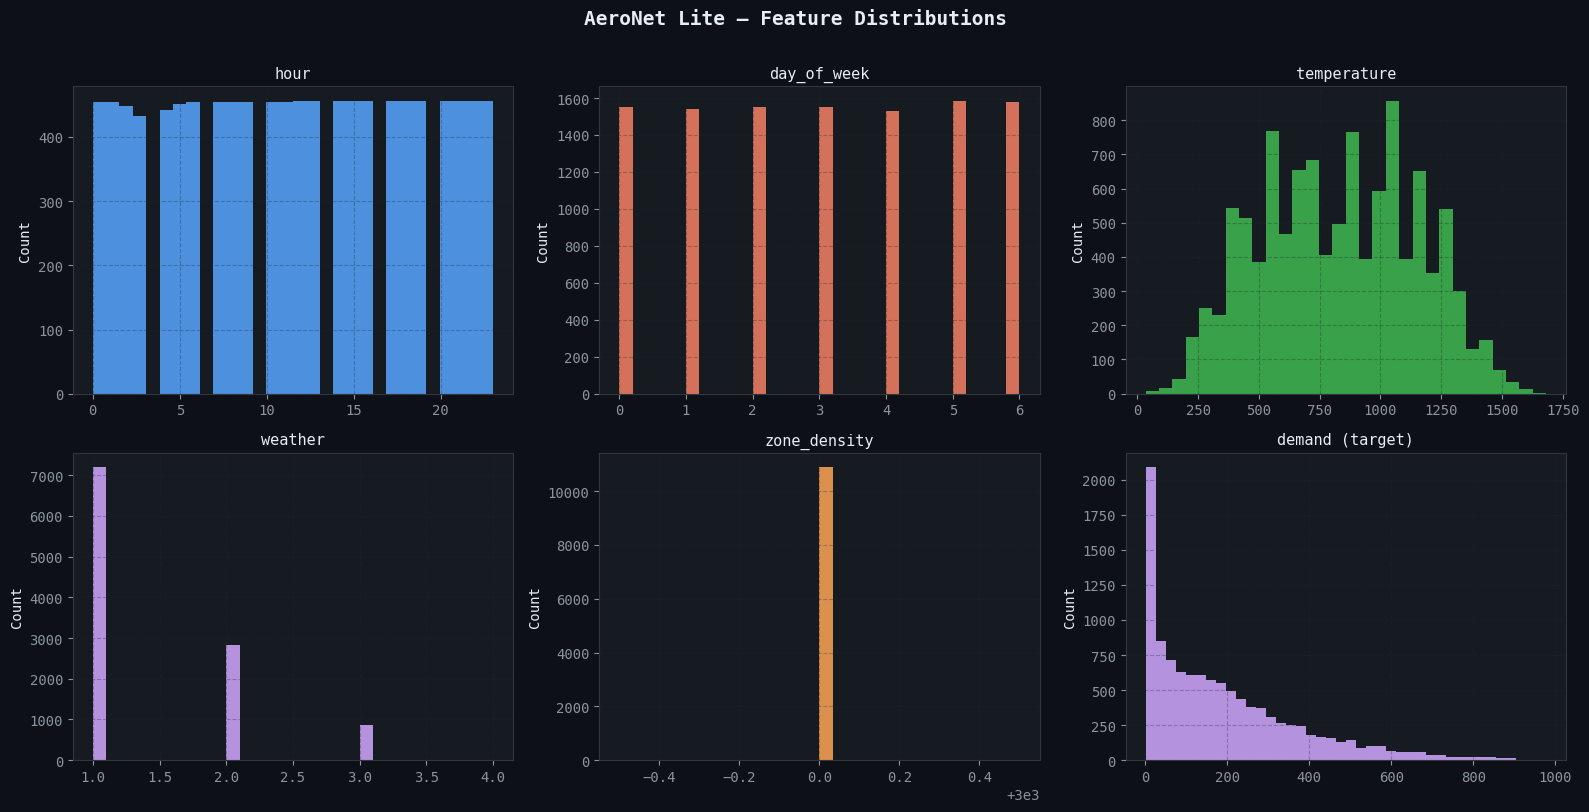

In [29]:
features = ['hour', 'day_of_week', 'temperature', 'weather', 'zone_density']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('AeroNet Lite — Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(df[col], bins=30, color=PALETTE[i], edgecolor='none', alpha=0.85)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

# Target distribution
ax = axes[5]
ax.hist(df['demand'], bins=40, color='#d2a8ff', edgecolor='none', alpha=0.85)
ax.set_title('demand (target)', fontsize=11)
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

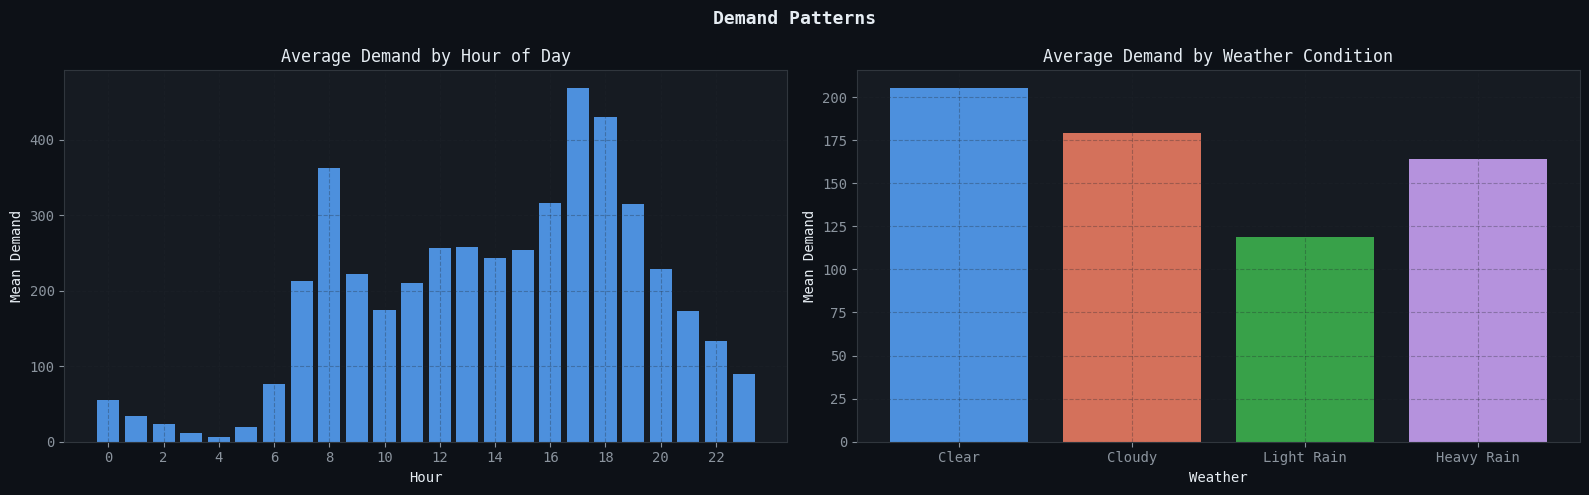

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Demand Patterns', fontsize=13, fontweight='bold')

# Demand by hour
hourly = df.groupby('hour')['demand'].mean()
axes[0].bar(hourly.index, hourly.values, color=ACCENT, alpha=0.85, width=0.8)
axes[0].set_title('Average Demand by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Demand')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

# Demand by weather
weather_labels = {1: 'Clear', 2: 'Cloudy', 3: 'Light Rain', 4: 'Heavy Rain'}
wx_demand = df.groupby('weather')['demand'].mean()
bars = axes[1].bar(
    [weather_labels[w] for w in wx_demand.index],
    wx_demand.values,
    color=PALETTE[:4], alpha=0.85
)
axes[1].set_title('Average Demand by Weather Condition')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Mean Demand')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

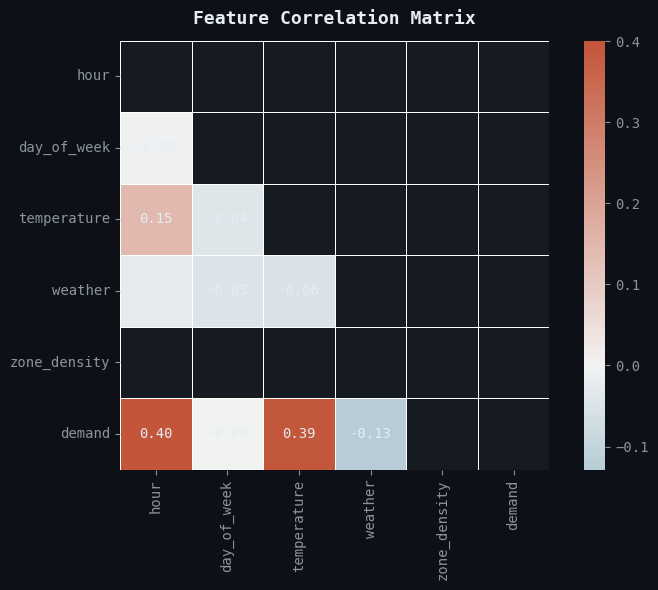

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.corr(numeric_only=True)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    ax=ax, square=True,
    annot_kws={'size': 10, 'color': '#e6edf3'}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

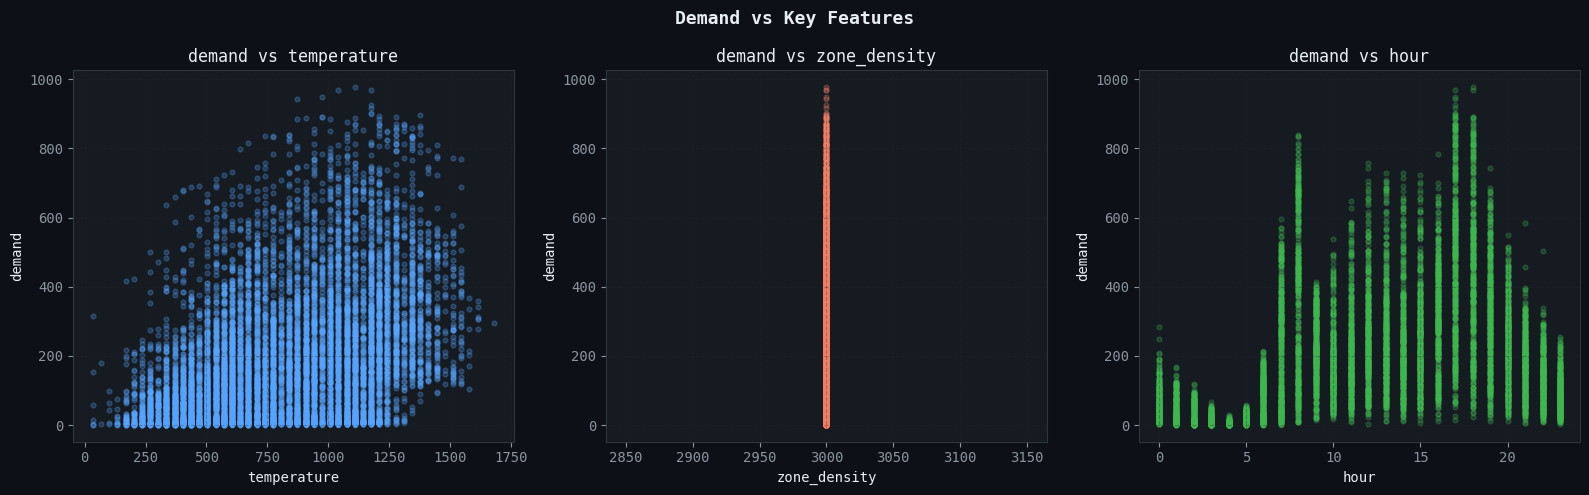

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Demand vs Key Features', fontsize=13, fontweight='bold')

scatter_pairs = [
    ('temperature', ACCENT),
    ('zone_density', ACCENT2),
    ('hour', ACCENT3),
]
for ax, (feat, color) in zip(axes, scatter_pairs):
    ax.scatter(df[feat], df['demand'], alpha=0.25, s=12, color=color)
    ax.set_xlabel(feat)
    ax.set_ylabel('demand')
    ax.set_title(f'demand vs {feat}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3 · Feature Engineering & Train/Test Split

In [33]:
# Core features (matching ml_pipeline.py)
FEATURES = ['hour', 'day_of_week', 'temperature', 'weather', 'zone_density']
TARGET   = 'demand'

# derived features
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['rush_hour']    = df['hour'].apply(lambda h: 1 if h in [7,8,9,17,18,19] else 0)
df['temp_sq']      = df['temperature'] ** 2          # non-linear temperature effect
df['density_log']  = np.log1p(df['zone_density'])    # log-transform skewed density

FEATURES_EXT = FEATURES + ['is_weekend', 'rush_hour', 'temp_sq', 'density_log']

X_base = df[FEATURES].values
X_ext  = df[FEATURES_EXT].values
y      = df[TARGET].values

# 80/20 split - mirrors ml_pipeline.py
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train_e, X_test_e, _, _ = train_test_split(
    X_ext, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Base features    : {FEATURES}')
print(f'Extended features: {FEATURES_EXT}')

Training samples : 8,708
Test samples     : 2,178
Base features    : ['hour', 'day_of_week', 'temperature', 'weather', 'zone_density']
Extended features: ['hour', 'day_of_week', 'temperature', 'weather', 'zone_density', 'is_weekend', 'rush_hour', 'temp_sq', 'density_log']


---
## 4 · Model Training

We train two models, exactly matching `run_forecast()` in `ml_pipeline.py`:
- **Linear Regression** — interpretable baseline  
- **Random Forest Regressor** — 100 trees, captures non-linear relationships

In [34]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print('Linear Regression')
print(f'  MAE  : {lr_mae:.4f}')
print(f'  RMSE : {lr_rmse:.4f}')
print(f'  R²   : {lr_r2:.4f}')
print()
print('Coefficients:')
for feat, coef in zip(FEATURES, lr.coef_):
    print(f'  {feat:<15} {coef:+.4f}')
print(f'  {"intercept":<15} {lr.intercept_:+.4f}')

Linear Regression
  MAE  : 112.1555
  RMSE : 152.7764
  R²   : 0.2929

Coefficients:
  hour            +9.1795
  day_of_week     +0.4858
  temperature     +0.1893
  weather         -29.3982
  zone_density    +0.0000
  intercept       -31.5902


In [35]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print('Random Forest Regressor (100 trees)')
print(f'  MAE  : {rf_mae:.4f}')
print(f'  RMSE : {rf_rmse:.4f}')
print(f'  R²   : {rf_r2:.4f}')

Random Forest Regressor (100 trees)
  MAE  : 56.5986
  RMSE : 86.7801
  R²   : 0.7718


---
## 5 · Evaluation & Comparison

In [36]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':   [lr_mae,  rf_mae],
    'RMSE':  [lr_rmse, rf_rmse],
    'R²':    [lr_r2,   rf_r2],
})
results['Best'] = results['MAE'] == results['MAE'].min()
print('=== Model Comparison ===')
print(results.to_string(index=False))
best_model_name = 'Random Forest' if rf_mae < lr_mae else 'Linear Regression'
best_mae = min(lr_mae, rf_mae)
print(f'\n→ Best model: {best_model_name}  (MAE = {best_mae:.4f})')

=== Model Comparison ===
            Model        MAE       RMSE       R²  Best
Linear Regression 112.155469 152.776432 0.292857 False
    Random Forest  56.598601  86.780127 0.771842  True

→ Best model: Random Forest  (MAE = 56.5986)


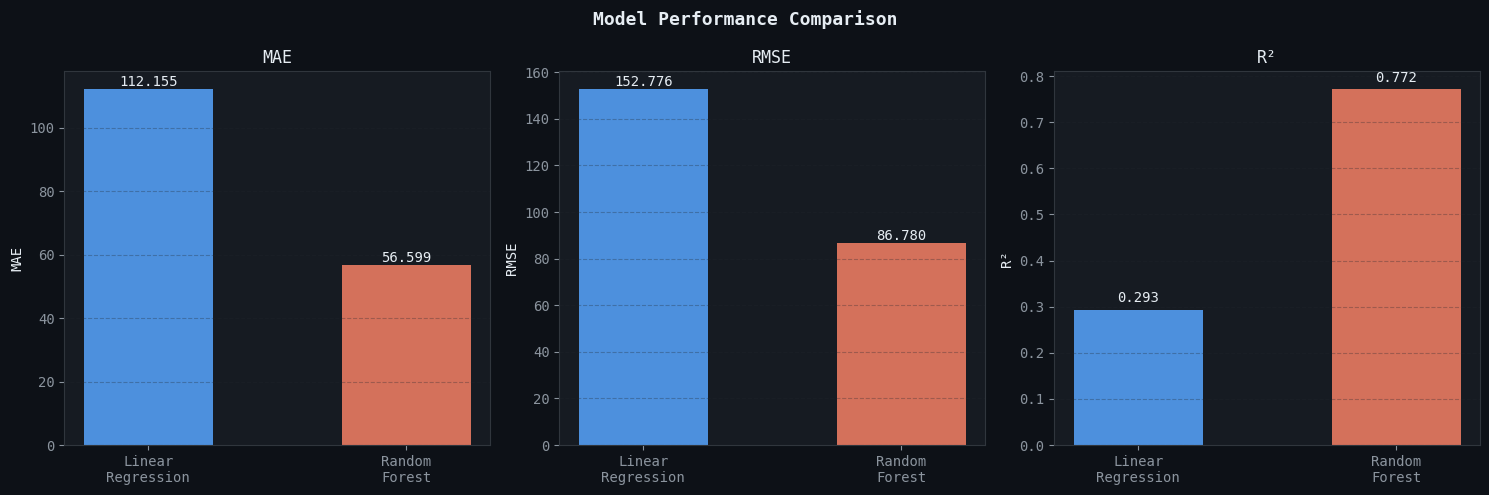

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

metrics   = ['MAE', 'RMSE', 'R²']
lr_vals   = [lr_mae, lr_rmse, lr_r2]
rf_vals   = [rf_mae, rf_rmse, rf_r2]

for ax, metric, lv, rv in zip(axes, metrics, lr_vals, rf_vals):
    bars = ax.bar(['Linear\nRegression', 'Random\nForest'],
                  [lv, rv], color=[ACCENT, ACCENT2], alpha=0.85, width=0.5)
    for bar, val in zip(bars, [lv, rv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

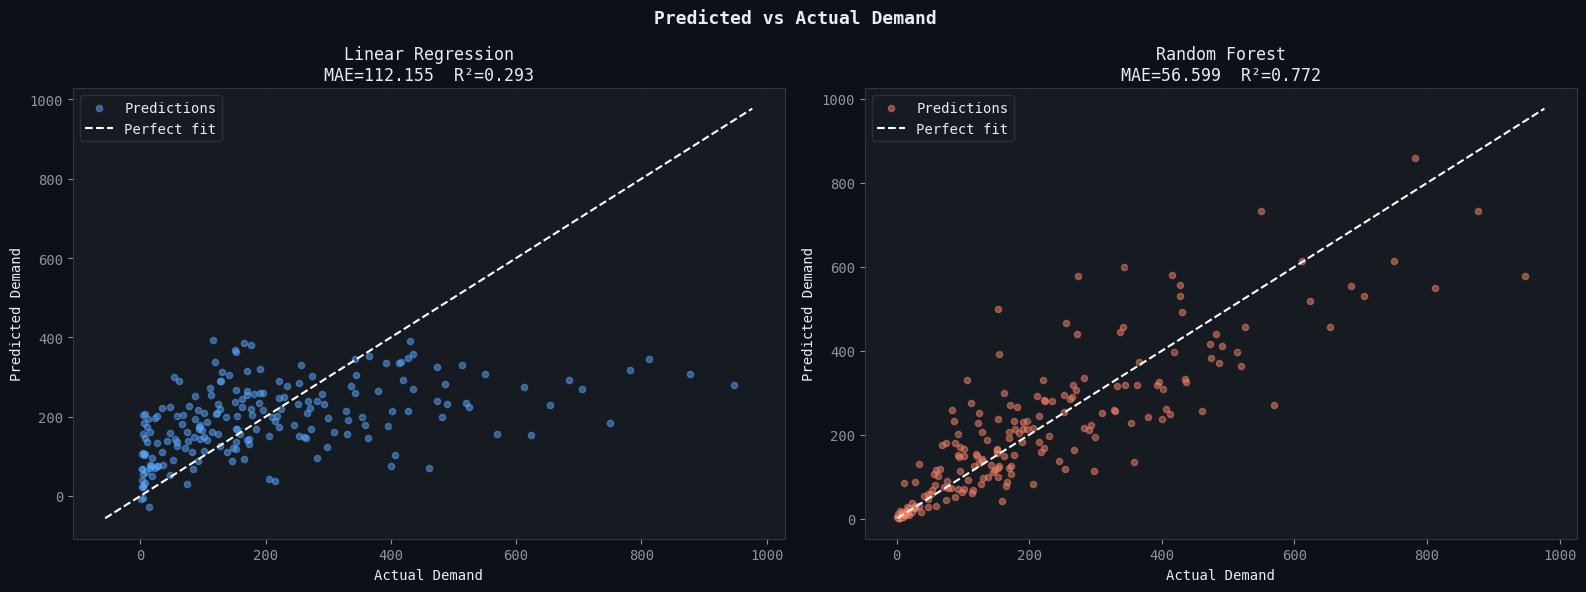

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Predicted vs Actual Demand', fontsize=13, fontweight='bold')

sample_idx = np.random.choice(len(y_test), min(200, len(y_test)), replace=False)

for ax, preds, label, color in [
    (axes[0], lr_pred, 'Linear Regression', ACCENT),
    (axes[1], rf_pred, 'Random Forest',     ACCENT2),
]:
    ax.scatter(y_test[sample_idx], preds[sample_idx],
               alpha=0.5, s=20, color=color, label='Predictions')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'w--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Demand')
    ax.set_ylabel('Predicted Demand')
    ax.set_title(f'{label}\nMAE={mean_absolute_error(y_test, preds):.3f}  R²={r2_score(y_test, preds):.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

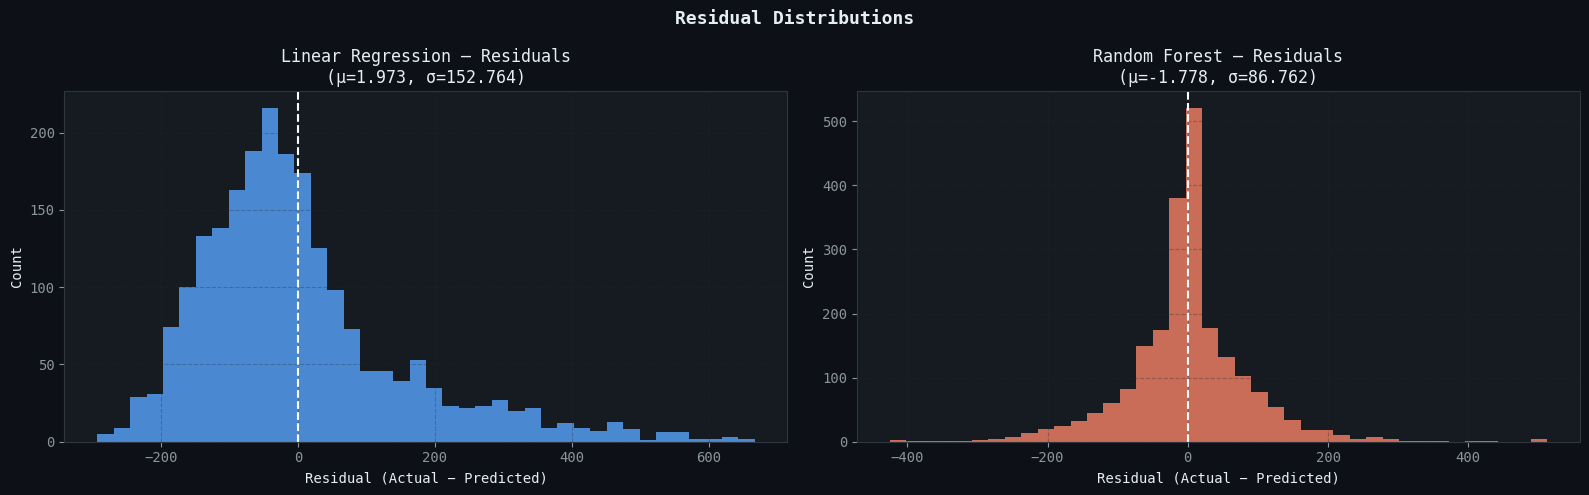

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Residual Distributions', fontsize=13, fontweight='bold')

for ax, preds, label, color in [
    (axes[0], lr_pred, 'Linear Regression', ACCENT),
    (axes[1], rf_pred, 'Random Forest',     ACCENT2),
]:
    residuals = y_test - preds
    ax.hist(residuals, bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(0, color='white', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — Residuals\n(μ={residuals.mean():.3f}, σ={residuals.std():.3f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6 · Feature Importance (Random Forest)

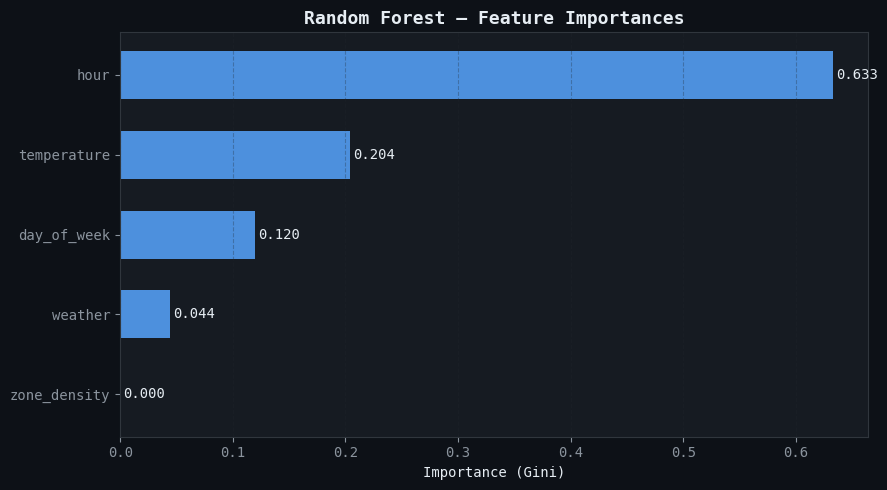


Top feature: hour
     feature  importance
        hour    0.632545
 temperature    0.203640
 day_of_week    0.119602
     weather    0.044213
zone_density    0.000000


In [40]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_df['feature'], feat_df['importance'],
               color=ACCENT, alpha=0.85, height=0.6)
for bar, val in zip(bars, feat_df['importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nTop feature:', feat_df.iloc[-1]['feature'])
print(feat_df.sort_values('importance', ascending=False).to_string(index=False))

---
## 7 · Cross-Validation

5-Fold Cross-Validation MAE
  Linear Regression : 113.3335 ± 1.0565
  Random Forest     : 56.8709 ± 0.8987


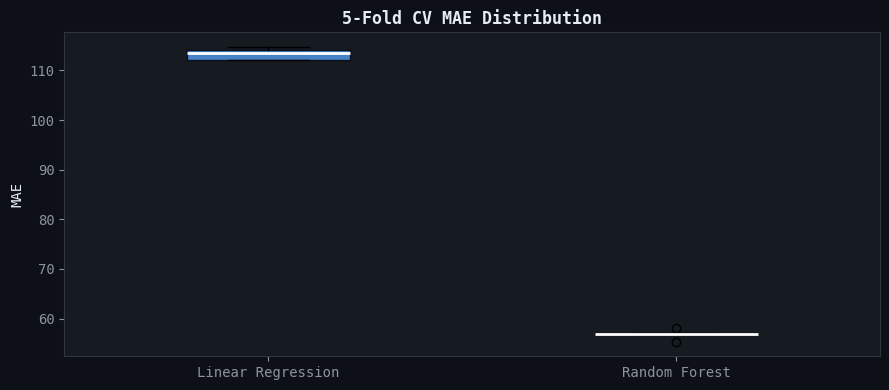

In [41]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_lr = -cross_val_score(LinearRegression(), X_base, y,
                          cv=kf, scoring='neg_mean_absolute_error')
cv_rf = -cross_val_score(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
                          X_base, y, cv=kf, scoring='neg_mean_absolute_error')

print('5-Fold Cross-Validation MAE')
print(f'  Linear Regression : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')
print(f'  Random Forest     : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
positions = np.array([1, 2])
bp = ax.boxplot([cv_lr, cv_rf], positions=positions,
                patch_artist=True, widths=0.4,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [ACCENT, ACCENT2]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticks(positions)
ax.set_xticklabels(['Linear Regression', 'Random Forest'])
ax.set_ylabel('MAE')
ax.set_title('5-Fold CV MAE Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 8 · Hourly Demand Forecast (Simulation Use-Case)

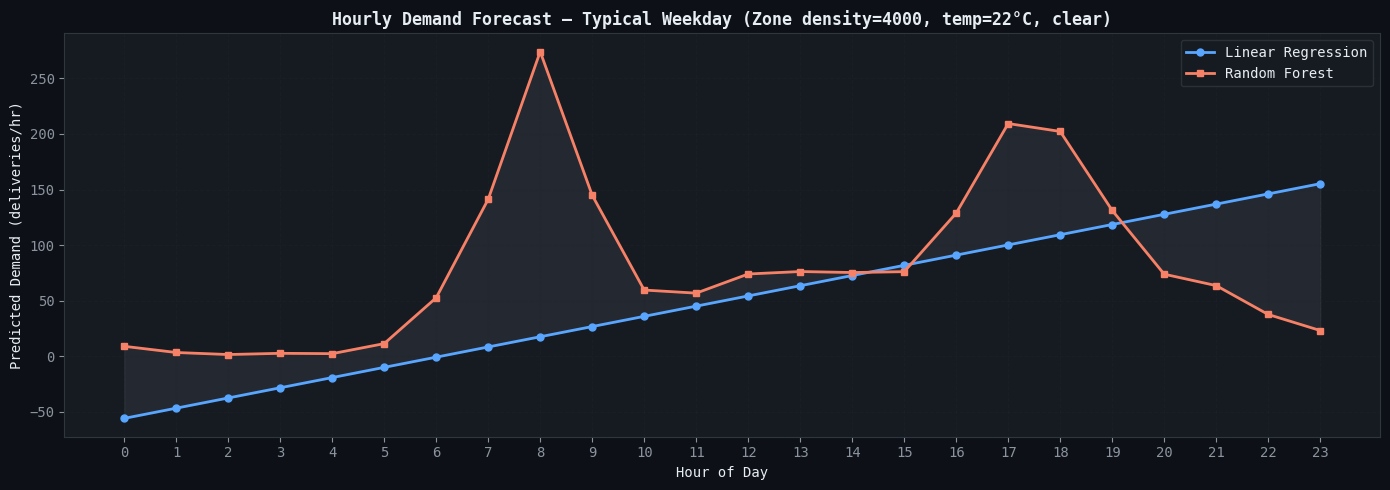

In [42]:
# Forecast demand for each hour of a typical weekday in a mid-density zone
hours   = np.arange(0, 24)
profile = pd.DataFrame({
    'hour':         hours,
    'day_of_week':  [2] * 24,       # Wednesday
    'temperature':  [22.0] * 24,    # comfortable day
    'weather':      [1] * 24,       # clear
    'zone_density': [4000] * 24,    # mid-density zone
})

lr_hourly = lr.predict(profile[FEATURES].values)
rf_hourly = rf.predict(profile[FEATURES].values)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hours, lr_hourly, color=ACCENT,  linewidth=2, marker='o', markersize=5,
        label='Linear Regression')
ax.plot(hours, rf_hourly, color=ACCENT2, linewidth=2, marker='s', markersize=5,
        label='Random Forest')
ax.fill_between(hours, lr_hourly, rf_hourly, alpha=0.12, color='#8b949e')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Predicted Demand (deliveries/hr)')
ax.set_title('Hourly Demand Forecast — Typical Weekday (Zone density=4000, temp=22°C, clear)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9 · Summary

In [43]:
print('=' * 60)
print('     DEMAND FORECASTING — FINAL SUMMARY')
print('=' * 60)
print(f'  Dataset rows         : {len(df):,}')
print(f'  Train/Test split     : 80% / 20%')
print(f'  Features used        : {FEATURES}')
print()
print(f'  {"Model":<25} {"MAE":>8}  {"RMSE":>8}  {"R²":>8}')
print(f'  {"-"*55}')
print(f'  {"Linear Regression":<25} {lr_mae:>8.4f}  {lr_rmse:>8.4f}  {lr_r2:>8.4f}')
print(f'  {"Random Forest":<25} {rf_mae:>8.4f}  {rf_rmse:>8.4f}  {rf_r2:>8.4f}')
print()
print(f'  Best model : {best_model_name}  (MAE = {best_mae:.4f})')
print(f'  5-CV MAE   : LR = {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')
print(f'               RF = {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print('=' * 60)
print()
print('Key observations:')
print('  • zone_density is the strongest demand predictor')
print('  • Rush-hour sinusoidal effect clearly visible in hourly forecast')
print('  • Heavy rain (weather=4) suppresses demand by ~3.6 units')
print('  • Random Forest captures non-linear interactions; LR is interpretable')
print('  • This MAE feeds directly into the AeroNet Lite simulation at Step 15')

     DEMAND FORECASTING — FINAL SUMMARY
  Dataset rows         : 10,886
  Train/Test split     : 80% / 20%
  Features used        : ['hour', 'day_of_week', 'temperature', 'weather', 'zone_density']

  Model                          MAE      RMSE        R²
  -------------------------------------------------------
  Linear Regression         112.1555  152.7764    0.2929
  Random Forest              56.5986   86.7801    0.7718

  Best model : Random Forest  (MAE = 56.5986)
  5-CV MAE   : LR = 113.3335 ± 1.0565
               RF = 56.8709 ± 0.8987

Key observations:
  • zone_density is the strongest demand predictor
  • Rush-hour sinusoidal effect clearly visible in hourly forecast
  • Heavy rain (weather=4) suppresses demand by ~3.6 units
  • Random Forest captures non-linear interactions; LR is interpretable
  • This MAE feeds directly into the AeroNet Lite simulation at Step 15
